# COMP8325 Applications of Artificial Intelligence for Cyber Security
## Group 13
# Task 1: Model Training


## Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
import time
import gc
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBClassifier
RANDOM_STATE = 42

## Load Dataset

In [8]:
# Load the dataset
data = np.load('bodmas.npz')
print('Keys in the dataset:', list(data.keys()))

# Extract features and labels
X_all = data['X'] # Feature matrix
y_binary = data['y'] # Binary labels: 0 = benign, 1 = malignant

# Encode the labels if they are not already in numeric format
print(f'Feature matrix shape: {X_all.shape}')
print(f'Binary labels shape: {y_binary.shape}')
print(f'Benign samples: {(y_binary == 0).sum()}')
print(f'Malignant samples: {(y_binary == 1).sum()}')

Keys in the dataset: ['X', 'y']
Feature matrix shape: (134435, 2381)
Binary labels shape: (134435,)
Benign samples: 77142
Malignant samples: 57293


## Load Metadata and Categories

In [9]:
# Load metadata
metadata = pd.read_csv('bodmas_metadata.csv')
metadata = metadata.rename(columns={'sha': 'sha256'})

# Load malware category labels
categories = pd.read_csv('bodmas_malware_category.csv')

# Display dataset information
print(f'Metadata shape: {metadata.shape}')
print(f'Categories shape: {categories.shape}')
print('\nCategory distribution: ')
print(categories["category"].value_counts())


Metadata shape: (134435, 3)
Categories shape: (57293, 2)

Category distribution: 
category
trojan                29972
worm                  16697
backdoor               7331
downloader             1031
ransomware              821
dropper                 715
informationstealer      448
virus                   192
pua                      29
cryptominer              20
p2p-worm                 16
exploit                  12
trojan-gamethief          6
rootkit                   3
Name: count, dtype: int64


## Data Preprocessing

Number of labelled samples: 134435
Dropped samples due to missing labels: 0
Final feature matrix shape: (134435, 2381)
Final labels shape: (134435,)
Nan count after cleaning: 0
Inf count after cleaning: 0
Features before selection: 2381
Features after selection: 1501

Classes (15): ['backdoor' 'benign' 'cryptominer' 'downloader' 'dropper' 'exploit'
 'informationstealer' 'p2p-worm' 'pua' 'ransomware' 'rootkit' 'trojan'
 'trojan-gamethief' 'virus' 'worm']


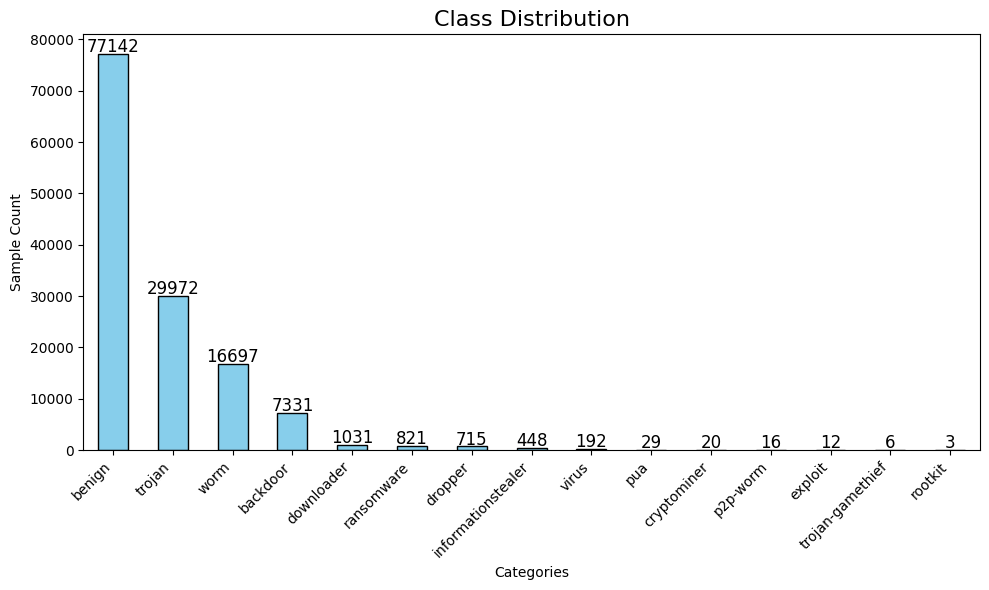

In [10]:
# Merge categories labels with metadata
metadata['binary_label'] = y_binary
meta_merged = metadata.merge(categories, on='sha256', how='left')
meta_merged.loc[meta_merged['binary_label'] == 0, 'category'] = 'benign'

# Drop rows with missing category labels
labelled_mask = meta_merged['category'].notna()
print(f'Number of labelled samples: {labelled_mask.sum()}')
print(f'Dropped samples due to missing labels: {(~labelled_mask).sum()}')

X = X_all[labelled_mask.values]
y_labels = meta_merged.loc[labelled_mask, 'category'].values
print(f'Final feature matrix shape: {X.shape}')
print(f'Final labels shape: {y_labels.shape}')

# Replace Nan and Inf values with LIEF features
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
print(f'Nan count after cleaning: {np.isnan(X).sum()}')
print(f'Inf count after cleaning: {np.isinf(X).sum()}')

print(f'Features before selection: {X.shape[1]}')
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)
print(f'Features after selection: {X_selected.shape[1]}')
joblib.dump(selector, 'variance_selector.pkl')
del X_all
gc.collect()

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_
print(f'\nClasses ({len(class_names)}): {class_names}')

# class distribution plot
cat_count = pd.Series(y_labels).value_counts()
plt.figure(figsize=(10, 6))
ax = cat_count.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution', fontsize=16)
plt.xlabel('Categories')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


## Train-Test Split

Training samples: 107548
Test samples: 26887
Features: 1501

Class distribution in Train and Test sets:
                    Train   Test  Train %  Test %
backdoor             5865   1466     5.45    5.45
benign              61714  15428    57.38   57.38
cryptominer            16      4     0.01    0.01
downloader            825    206     0.77    0.77
dropper               572    143     0.53    0.53
exploit                10      2     0.01    0.01
informationstealer    358     90     0.33    0.33
p2p-worm               13      3     0.01    0.01
pua                    23      6     0.02    0.02
ransomware            657    164     0.61    0.61
rootkit                 2      1     0.00    0.00
trojan              23977   5995    22.29   22.30
trojan-gamethief        5      1     0.00    0.00
virus                 153     39     0.14    0.15
worm                13358   3339    12.42   12.42


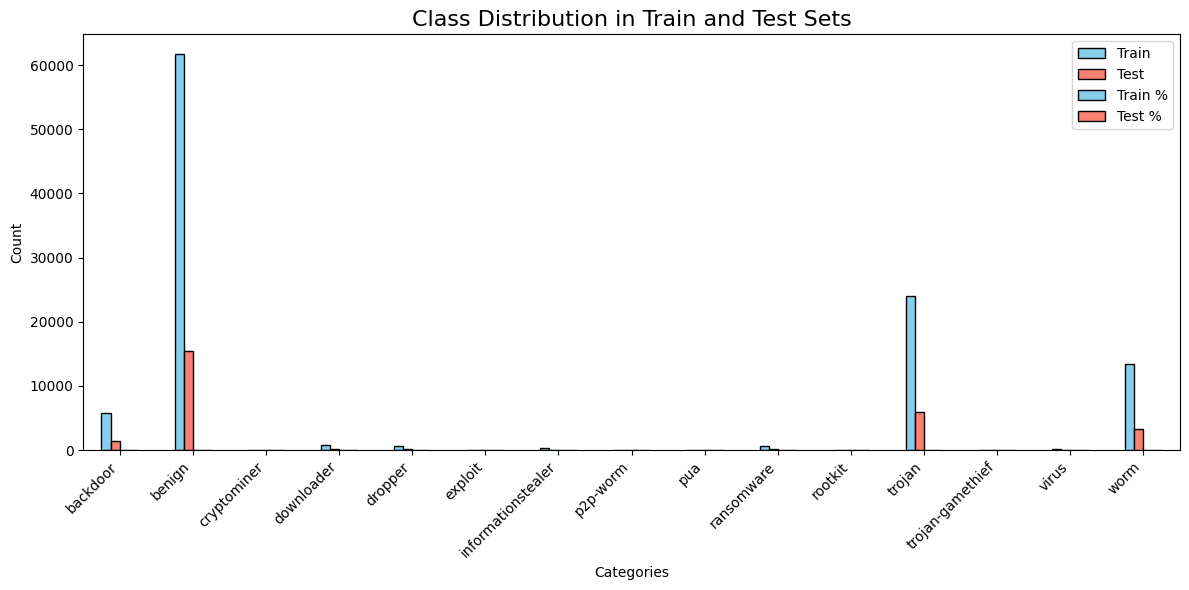

In [11]:
# 80/20 split - preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Features: {X_train.shape[1]}')

# Verify class distribution in train and test sets
train_dist = pd.Series(label_encoder.inverse_transform(y_train)).value_counts()
test_dist = pd.Series(label_encoder.inverse_transform(y_test)).value_counts()
split_check = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
split_check['Train %'] = (split_check['Train'] / split_check['Train'].sum() * 100).round(2)
split_check['Test %'] = (split_check['Test'] / split_check['Test'].sum() * 100).round(2)
split_check.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Class Distribution in Train and Test Sets', fontsize=16)
plt.xlabel('Categories')
print('\nClass distribution in Train and Test sets:')
print(split_check)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Model 1 - Random Forest

In [12]:
param = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

random_rf = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = param,
    n_iter              = 10,
    scoring             = 'accuracy',
    cv                  = cv,
    n_jobs              = 1,
    random_state        = RANDOM_STATE,
    verbose             = 1
)

start = time.time()
random_rf.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Random Forest Training Time: {elapsed:.2f} s")
print(f"Best parameters  : {random_rf.best_params_}")
print(f"Accuracy : {random_rf.best_score_ * 100:.2f}%")

rf        = random_rf.best_estimator_
y_pred_rf = rf.predict(X_test)
print(f"Test accuracy    : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest Training Time: 150.43 s
Best parameters  : {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None}
Accuracy : 97.23%
Test accuracy    : 97.33%
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.96      1466
            benign       0.99      1.00      1.00     15428
       cryptominer       0.80      1.00      0.89         4
        downloader       0.91      0.86      0.89       206
           dropper       0.72      0.77      0.75       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.89      0.79      0.84        90
          p2p-worm       0.00      0.00      0.00         3
               pua       0.50      0.17      0.25         6
        ransomware       0.97      0.89      0.93       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.96      0.93      0.94   

## Model 2 Xgboost

In [13]:
param = {
    'n_estimators' : [50, 100],
    'max_depth'    : [3, 4],
    'learning_rate': [0.1, 0.2],
}

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

random_xgb = RandomizedSearchCV(
    estimator           = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'),
    param_distributions = param,
    n_iter              = 5,
    scoring             = 'accuracy',
    cv                  = cv,
    n_jobs              = 1,
    random_state        = RANDOM_STATE,
    verbose             = 1
)

start = time.time()
random_xgb.fit(X_train, y_train)
elapsed = time.time() - start
print(f"XGBoost training time: {elapsed:.2f} s")
print(f"Best parameters  : {random_xgb.best_params_}")
print(f"Best CV accuracy : {random_xgb.best_score_ * 100:.2f}%")

xgb        = random_xgb.best_estimator_
y_pred_xgb = xgb.predict(X_test)
print(f"Test accuracy    : {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

Fitting 2 folds for each of 5 candidates, totalling 10 fits
XGBoost training time: 262.00 s
Best parameters  : {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2}
Best CV accuracy : 96.68%
Test accuracy    : 97.03%
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      1.00     15428
       cryptominer       0.80      1.00      0.89         4
        downloader       0.89      0.71      0.79       206
           dropper       0.88      0.69      0.77       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.91      0.78      0.84        90
          p2p-worm       0.00      0.00      0.00         3
               pua       1.00      0.33      0.50         6
        ransomware       0.94      0.88      0.91       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.95      0.93      0.94      5

## Evaluation Function and Models

In [14]:
## Evaluation Function and Models

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, class_names):
  
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Overall accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print("=" * 80)
    print(f"{model_name} Evaluation")
    print("=" * 80)
    print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
    print(f"Test Accuracy:     {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        zero_division=0
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred, labels=np.arange(len(class_names)))

    # Calculate TPR and FPR for each class using one-vs-rest method
    metrics = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        support = TP + FN

        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

        metrics.append({
            "Category": class_name,
            "Support": support,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN,
            "TPR": round(tpr, 4),
            "FPR": round(fpr, 4)
        })

    metrics_df = pd.DataFrame(metrics)

    print("\nPer-Class TPR and FPR:")
    display(metrics_df[["Category", "Support", "TPR", "FPR"]])

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(14, 10))
    ConfusionMatrixDisplay(
        confusion_matrix = cm, 
        display_labels   = class_names
    ).plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "predictions": y_test_pred,
        "confusion_matrix": cm,
        "per_class_metrics": metrics_df
    }



Random Forest Evaluation
Training Accuracy: 0.9998 (99.98%)
Test Accuracy:     0.9733 (97.33%)

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.96      1466
            benign       0.99      1.00      1.00     15428
       cryptominer       0.80      1.00      0.89         4
        downloader       0.91      0.86      0.89       206
           dropper       0.72      0.77      0.75       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.89      0.79      0.84        90
          p2p-worm       0.00      0.00      0.00         3
               pua       0.50      0.17      0.25         6
        ransomware       0.97      0.89      0.93       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.96      0.93      0.94      5995
  trojan-gamethief       1.00      1.00      1.00         1
             virus       1.00      0.97 

,Category,Support,TPR,FPR
0,backdoor,1466,0.9707,0.0033
1,benign,15428,0.9998,0.0079
2,cryptominer,4,1.0000,0.0000
3,downloader,206,0.8641,0.0006
4,dropper,143,0.7692,0.0016
5,exploit,2,1.0000,0.0000
6,informationstealer,90,0.7889,0.0003
7,p2p-worm,3,0.0000,0.0000
8,pua,6,0.1667,0.0000
9,ransomware,164,0.8902,0.0002


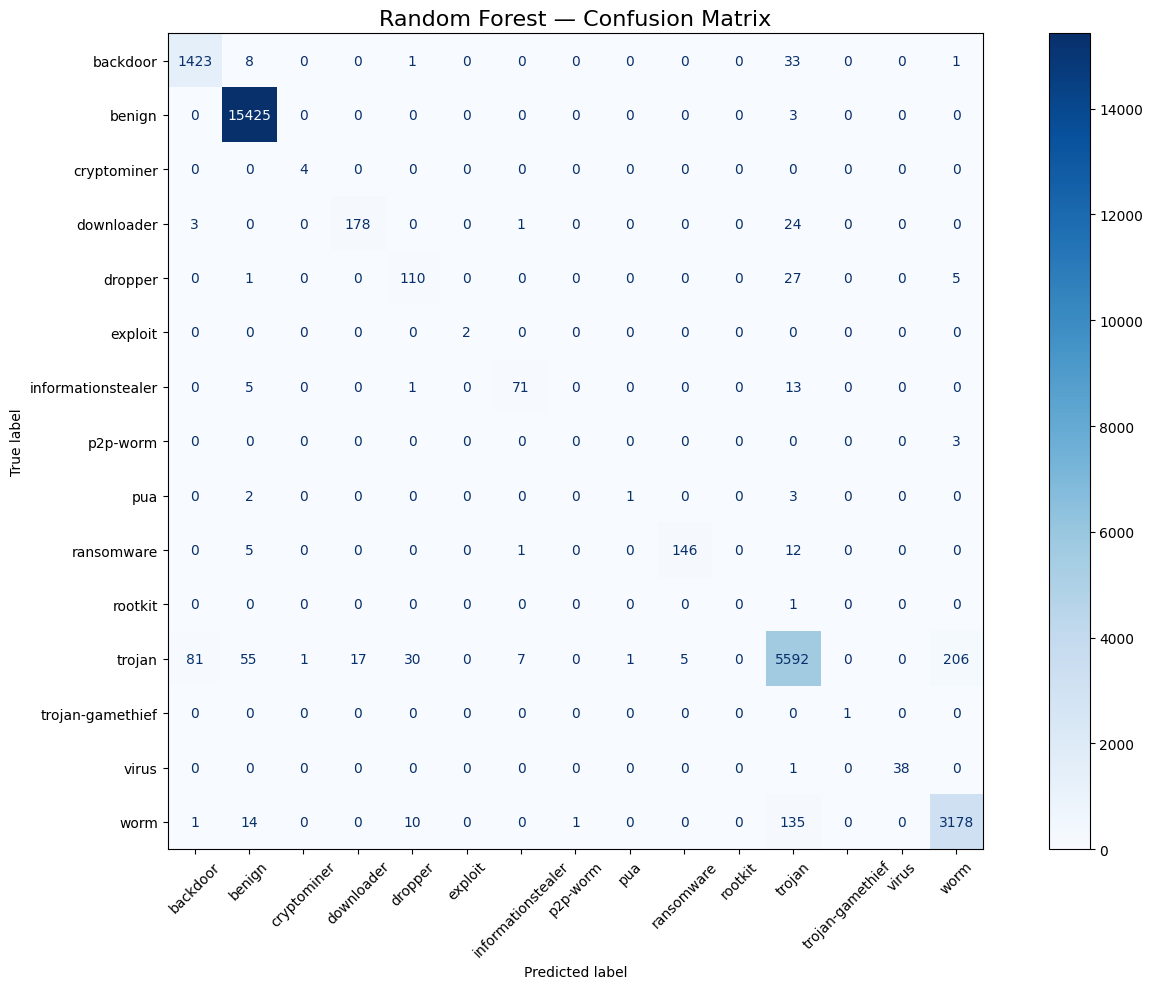

XGBoost Evaluation
Training Accuracy: 0.9729 (97.29%)
Test Accuracy:     0.9703 (97.03%)

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.95      1466
            benign       0.99      1.00      1.00     15428
       cryptominer       0.80      1.00      0.89         4
        downloader       0.89      0.71      0.79       206
           dropper       0.88      0.69      0.77       143
           exploit       1.00      1.00      1.00         2
informationstealer       0.91      0.78      0.84        90
          p2p-worm       0.00      0.00      0.00         3
               pua       1.00      0.33      0.50         6
        ransomware       0.94      0.88      0.91       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.95      0.93      0.94      5995
  trojan-gamethief       1.00      1.00      1.00         1
             virus       1.00      1.00      1

,Category,Support,TPR,FPR
0,backdoor,1466,0.9686,0.0037
1,benign,15428,0.9964,0.0069
2,cryptominer,4,1.0000,0.0000
3,downloader,206,0.7136,0.0007
4,dropper,143,0.6853,0.0005
5,exploit,2,1.0000,0.0000
6,informationstealer,90,0.7778,0.0003
7,p2p-worm,3,0.0000,0.0000
8,pua,6,0.3333,0.0000
9,ransomware,164,0.8780,0.0003


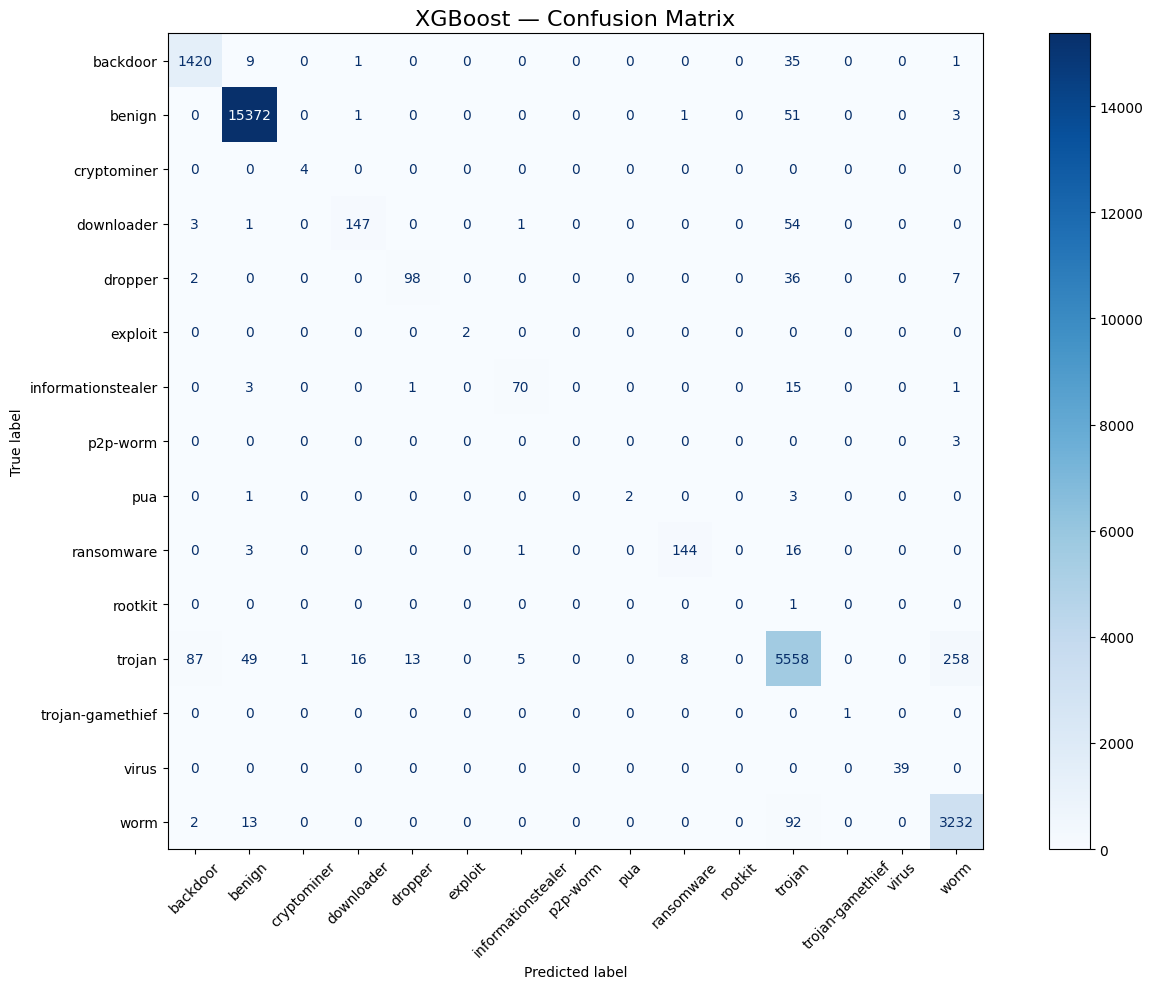

In [15]:
# Evaluate both trained models

rf_results = evaluate_model(
    model=rf,
    model_name="Random Forest",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names
)

xgb_results = evaluate_model(
    model=xgb,
    model_name="XGBoost",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names
)

## Model Comparison

In [16]:
# save artefacts for Task 2
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(xgb, 'xgboost_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(selector, 'variance_selector.pkl')
print("Models and encoders saved for Task 2.")

Models and encoders saved for Task 2.


,Model,Training Accuracy,Test Accuracy
0,Random Forest,0.9998,0.9733
1,XGBoost,0.9729,0.9703


,Category,RF Support,RF TPR,RF FPR,XGB Support,XGB TPR,XGB FPR
0,backdoor,1466,0.9707,0.0033,1466,0.9686,0.0037
1,benign,15428,0.9998,0.0079,15428,0.9964,0.0069
2,cryptominer,4,1.0000,0.0000,4,1.0000,0.0000
3,downloader,206,0.8641,0.0006,206,0.7136,0.0007
4,dropper,143,0.7692,0.0016,143,0.6853,0.0005
5,exploit,2,1.0000,0.0000,2,1.0000,0.0000
6,informationstealer,90,0.7889,0.0003,90,0.7778,0.0003
7,p2p-worm,3,0.0000,0.0000,3,0.0000,0.0000
8,pua,6,0.1667,0.0000,6,0.3333,0.0000
9,ransomware,164,0.8902,0.0002,164,0.8780,0.0003


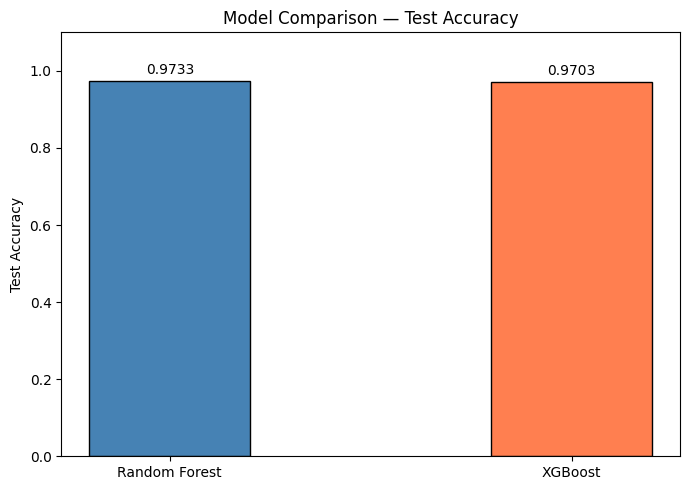

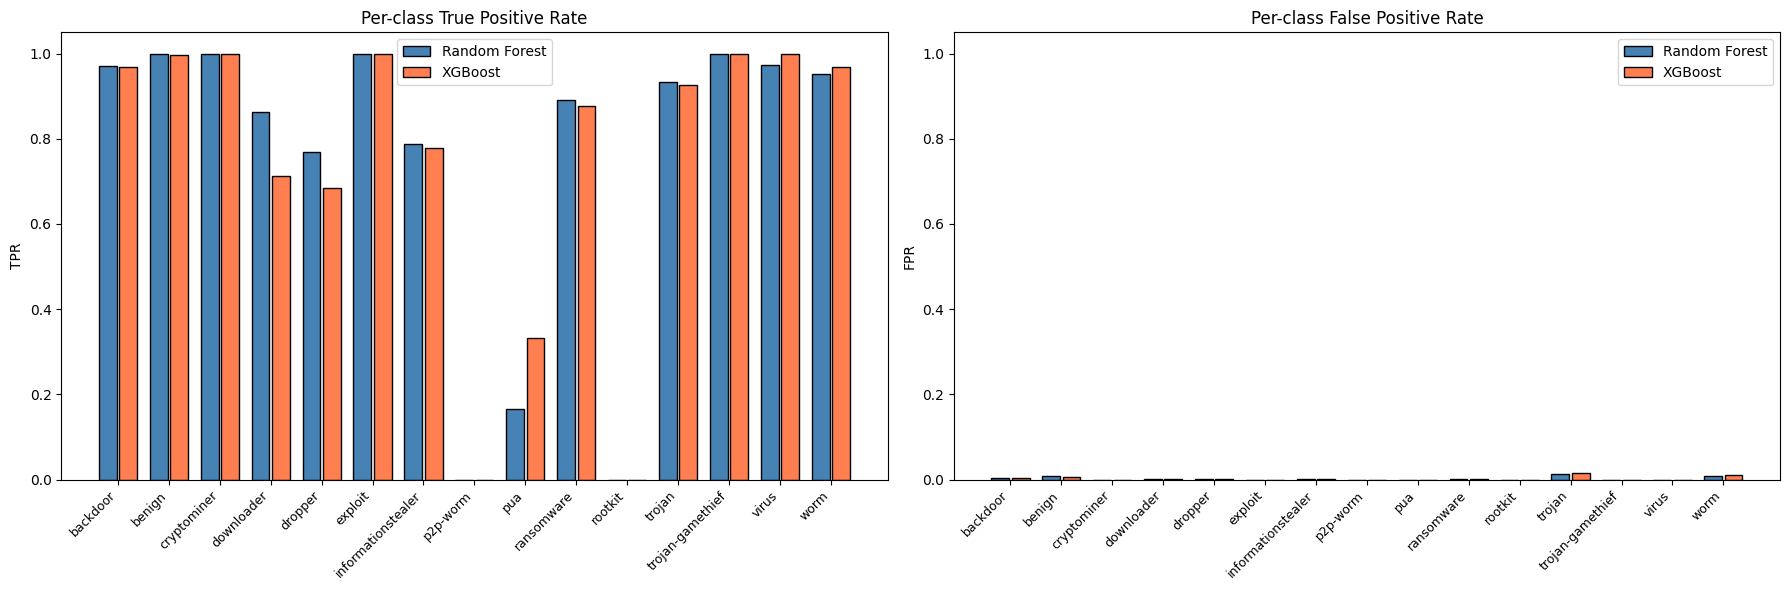

In [17]:
# Overall model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        rf_results["model_name"],
        xgb_results["model_name"]
    ],
    "Training Accuracy": [
        round(rf_results["train_accuracy"], 4),
        round(xgb_results["train_accuracy"], 4)
    ],
    "Test Accuracy": [
        round(rf_results["test_accuracy"], 4),
        round(xgb_results["test_accuracy"], 4)
    ]
})

display(model_comparison)

# Per-class TPR/FPR comparison table

rf_metrics = rf_results["per_class_metrics"][["Category", "Support", "TPR", "FPR"]].copy()
xgb_metrics = xgb_results["per_class_metrics"][["Category", "Support", "TPR", "FPR"]].copy()

rf_metrics = rf_metrics.rename(columns={
    "Support": "RF Support",
    "TPR": "RF TPR",
    "FPR": "RF FPR"
})

xgb_metrics = xgb_metrics.rename(columns={
    "Support": "XGB Support",
    "TPR": "XGB TPR",
    "FPR": "XGB FPR"
})

per_class_comparison = rf_metrics.merge(xgb_metrics, on="Category")

display(per_class_comparison)

# Bar chart: test accuracy comparison
fig, ax = plt.subplots(figsize=(7, 5))
models = ['Random Forest', 'XGBoost']
accs   = [rf_results['test_accuracy'], xgb_results['test_accuracy']]
bars   = ax.bar(models, accs, color=['steelblue', 'coral'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy')
ax.bar_label(bars, fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

# Per-class TPR/FPR bar chart
rf_tpr  = rf_results['per_class_metrics']['TPR'].values
xgb_tpr = xgb_results['per_class_metrics']['TPR'].values
x_pos   = np.arange(len(class_names))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, rf_v, xgb_v, ylabel, title in [
    (axes[0], rf_tpr,  xgb_tpr, 'TPR', 'Per-class True Positive Rate'),
    (axes[1],
     rf_results['per_class_metrics']['FPR'].values,
     xgb_results['per_class_metrics']['FPR'].values,
     'FPR', 'Per-class False Positive Rate'),
]:
    ax.bar(x_pos - 0.2, rf_v,  0.35, label='Random Forest', color='steelblue', edgecolor='black')
    ax.bar(x_pos + 0.2, xgb_v, 0.35, label='XGBoost',       color='coral',     edgecolor='black')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


## Discussion
Random Forest and XGBoost were selected because both are suitable for multi-class classification on structured, high-dimensional malware feature data. Random Forest trains multiple decision trees using bootstrap samples and random feature selection. The final prediction is made through majority voting, which helps reduce variance and improves stability. This makes Random Forest less prone to overfitting and useful for analysing LIEF/EMBER-based static PE features. Its feature importance output also provides some interpretability by showing which extracted executable features contribute most to classification.

XGBoost uses a different approach by building decision trees sequentially. Each new tree attempts to correct the errors made by the previous trees using gradient boosting. Its regularisation parameters help control model complexity and reduce overfitting. Because of this, XGBoost is often effective on tabular datasets and can capture more complex relationships between malware features. However, it usually requires more careful hyperparameter tuning and may take longer to train than Random Forest.

The results show that XGBoost is expected to achieve stronger overall test accuracy because its boosting process can learn fine-grained feature interactions. Random Forest, however, may show a smaller difference between training and testing accuracy because ensemble averaging improves generalisation. Both models are likely to perform better on large classes such as benign, trojan, and worm, while minority classes such as rootkit, exploit, and trojan-gamethief may have lower TPR due to limited training examples. The benign class FPR is especially important in a real malware detection system because falsely classifying legitimate programs as malware can reduce user trust and affect normal system usage.